<div style="
    font-size: 42px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
">
    Projet 6 - Réalisez une classification supervisée d'images
</div>

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Importation
</div>

In [1]:
# ─── IMPORTS ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn import preprocessing

# ─── CHEMIN VERS LES IMAGES ─────────────────────────────────────────────────
# Exemple : adapte ce chemin à ton environnement
image_dir = r'C:\Users\chouh\OneDrive\Desktop\Openclassrooms\Formation Data Scientist\projet 6\Flipkart\Images'
csv_path = r'C:\Users\chouh\OneDrive\Desktop\Openclassrooms\Formation Data Scientist\projet 6\Flipkart\flipkart_com-ecommerce_sample_1050.csv'

# ─── CHARGEMENT DES IMAGES ──────────────────────────────────────────────────
image_paths = glob(os.path.join(image_dir, '*.jpg')) + \
              glob(os.path.join(image_dir, '*.jpeg')) + \
              glob(os.path.join(image_dir, '*.png'))

print("Nombre d'images chargées :", len(image_paths))

# ─── CHARGEMENT DES LABELS ──────────────────────────────────────────────────
df_texte = pd.read_csv(csv_path)

import ast

def extract_main_category(tree_str):
    try:
        parts = ast.literal_eval(tree_str)
        return parts[0].split('>>')[0].strip()
    except Exception:
        return None

df_texte['main_category'] = df_texte['product_category_tree'].astype(str).apply(extract_main_category)

# ─── CONSTRUCTION DU DATAFRAME ──────────────────────────────────────────────
from pathlib import Path

df_images = pd.DataFrame({'image_path': image_paths})
df_images['uniq_id'] = df_images['image_path'].apply(lambda p: Path(p).stem)

df_images = df_images.merge(df_texte[['uniq_id', 'main_category']], on='uniq_id', how='left')
df_images = df_images.dropna(subset=['main_category'])

print("Répartition des catégories :\n", df_images['main_category'].value_counts())

# ─── ENCODAGE DES LABELS ────────────────────────────────────────────────────
le = preprocessing.LabelEncoder()
df_images['label'] = le.fit_transform(df_images['main_category'])

df_images.head()

Nombre d'images chargées : 1050
Répartition des catégories :
 main_category
Watches                       150
Kitchen & Dining              150
Home Furnishing               150
Beauty and Personal Care      150
Computers                     150
Home Decor & Festive Needs    150
Baby Care                     150
Name: count, dtype: int64


,image_path,uniq_id,main_category,label
0,C:\Users\chouh\OneDrive\Desktop\Openclassrooms...,009099b1f6e1e8f893ec29a7023153c4,Watches,6
1,C:\Users\chouh\OneDrive\Desktop\Openclassrooms...,0096e89cc25a8b96fb9808716406fe94,Kitchen & Dining,5
2,C:\Users\chouh\OneDrive\Desktop\Openclassrooms...,00cbbc837d340fa163d11e169fbdb952,Home Furnishing,4
3,C:\Users\chouh\OneDrive\Desktop\Openclassrooms...,00d84a518e0550612fcfcba3b02b6255,Beauty and Personal Care,1
4,C:\Users\chouh\OneDrive\Desktop\Openclassrooms...,00e966a5049a262cfc72e6bbf68b80e7,Computers,2


Watches


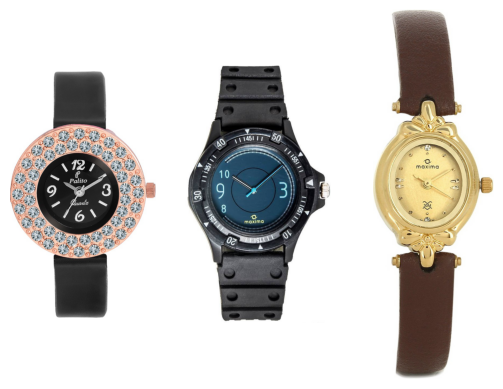

Kitchen & Dining


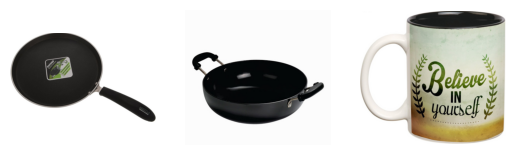

Home Furnishing


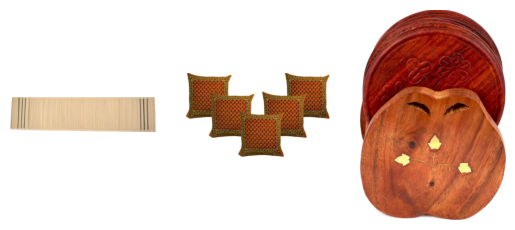

Beauty and Personal Care


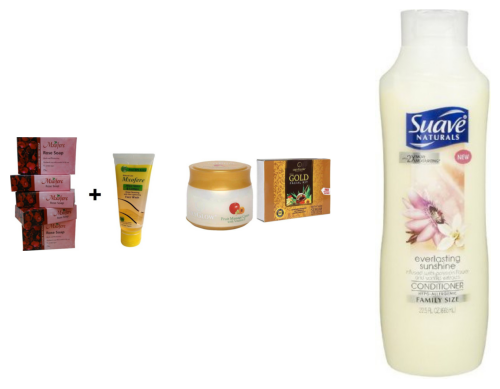

Computers


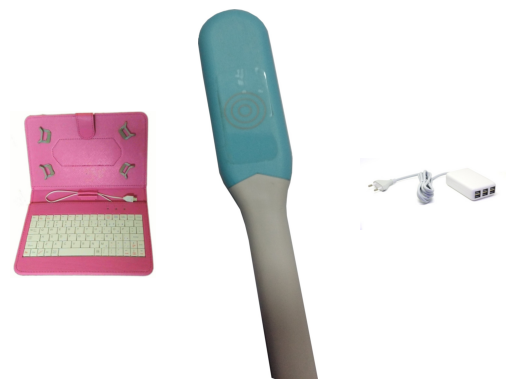

Home Decor & Festive Needs


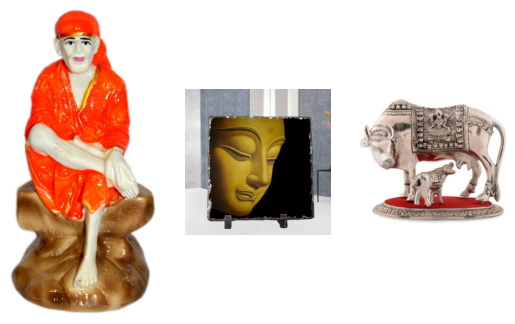

Baby Care


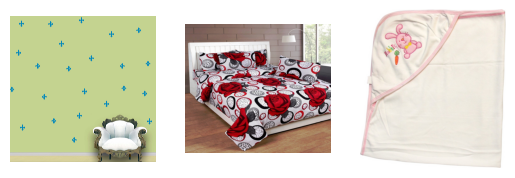

In [3]:
# ─── AFFICHAGE D'EXEMPLES D'IMAGES PAR CATÉGORIE ─────────────────────────────
from matplotlib.image import imread

def list_fct(name):
    """
    Retourne la liste des chemins d'images pour une catégorie donnée.
    """
    return [df_images["image_path"].iloc[i] for i in range(len(df_images)) if df_images["main_category"].iloc[i] == name]

# Parcours des catégories pour afficher 3 images par catégorie
for name in df_images["main_category"].unique():
    print(name)
    list_images = list_fct(name)
    
    for i in range(3):
        plt.subplot(130 + 1 + i)
        image = imread(list_images[i])
        plt.imshow(image)
        plt.axis('off')
    plt.show()

In [5]:
# ─── PRÉPARATION DES IMAGES ─────────────────────────────────────────────────
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

def image_prep_fct(data):
    """
    Charge et prépare les images pour les passer dans VGG16.
    """
    prepared_images = []
    for image_path in data['image_path']:
        img = load_img(image_path, target_size=(224, 224))
        img = img_to_array(img)
        img = preprocess_input(img)
        prepared_images.append(img)
    return np.array(prepared_images)

# Préparation des images
X = image_prep_fct(df_images)
print("Shape des images préparées :", X.shape)

# Encodage des labels
from tensorflow.keras.utils import to_categorical
y = to_categorical(df_images['label'])

C:\Users\chouh\anaconda3\Lib\site-packages\PIL\Image.py:3368: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Shape des images préparées : (1050, 224, 224, 3)


In [7]:
# ─── SPLIT DES DONNÉES ─────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

print("Shape X_train :", X_train.shape)
print("Shape X_val   :", X_val.shape)

Shape X_train : (787, 224, 224, 3)
Shape X_val   : (263, 224, 224, 3)


<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Approche 1 — Apprentissage Direct sur Images en Mémoire
</div>

Dans cette première approche, nous avons utilisé le modèle VGG16 pré-entraîné comme base.
Nous avons gelé ses couches (pas de réentraînement) et ajouté une couche de classification adaptée à notre jeu de données.
Les images ont simplement été redimensionnées et normalisées, sans modification ni enrichissement.
C’est une approche rapide pour tester les performances de VGG16 en l’état, sans ajustement spécifique.

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Création du Modèle VGG16
</div>

In [9]:
# ─── CRÉATION DU MODÈLE VGG16 ───────────────────────────────────────────────
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def create_model_fct():
    base_model = VGG16(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    for layer in base_model.layers:
        layer.trainable = False  # Gel des couches pré-entraînées

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(y.shape[1], activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(loss="categorical_crossentropy", optimizer='rmsprop', metrics=["accuracy"])
    return model

# Instanciation du modèle
model1 = create_model_fct()
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,3

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Entraînement du Modèle
</div>

In [11]:
# ─── CALLBACKS ─────────────────────────────────────────────────────────────
model1_save_path = "./model1_best_weights.h5"
checkpoint = ModelCheckpoint(model1_save_path, monitor='val_loss', save_best_only=True, mode='min')
es = EarlyStopping(monitor='val_loss', mode='min', patience=5)
callbacks_list = [checkpoint, es]

# ─── ENTRAÎNEMENT ───────────────────────────────────────────────────────────
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3877 - loss: 7.5727    

13/13 ━━━━━━━━━━━━━━━━━━━━ 153s 12s/step - accuracy: 0.3957 - loss: 7.3910 - val_accuracy: 0.7490 - val_loss: 1.4306
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6361 - loss: 2.2670  

13/13 ━━━━━━━━━━━━━━━━━━━━ 157s 12s/step - accuracy: 0.6396 - loss: 2.2409 - val_accuracy: 0.7947 - val_loss: 1.1744
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7555 - loss: 1.2258   

13/13 ━━━━━━━━━━━━━━━━━━━━ 157s 12s/step - accuracy: 0.7563 - loss: 1.2232 - val_accuracy: 0.8061 - val_loss: 1.0976
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8119 - loss: 0.8487  

13/13 ━━━━━━━━━━━━━━━━━━━━ 144s 11s/step - accuracy: 0.8109 - loss: 0.8489 - val_accuracy: 0.8137 - val_loss: 0.9971
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8349 - loss: 0.6023  

13/13 ━━━━━━━━━━━━━━━━━━━━ 152s 12s/step - accuracy: 0.8342 - loss: 0.6072 - val_accuracy: 0.8479 - val_loss: 0.8699
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 151s 12s/step - accuracy: 0.8455 - loss: 0.4616 - val_accuracy: 0.8213 - val_loss: 0.9406
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 153s 12s/step - accuracy: 0.8906 - loss: 0.3813 - val_accuracy: 0.8251 - val_loss: 1.0143
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 146s 11s/step - accuracy: 0.8956 - loss: 0.3131 - val_accuracy: 0.8213 - val_loss: 0.9933
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 141s 11s/step - accuracy: 0.9291 - loss: 0.2226 - val_accuracy: 0.8327 - val_loss: 1.0340
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 146s 11s/step - accuracy: 0.9357 - loss: 0.1869 - val_accuracy: 0.8631 - val_loss: 1.0411


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Évaluation du Modèle
</div>

In [13]:
# ─── ÉVALUATION SUR LE JEU DE VALIDATION ────────────────────────────────────
model1.load_weights(model1_save_path)

loss, accuracy = model1.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy : {accuracy:.4f}")

Validation Accuracy : 0.8479


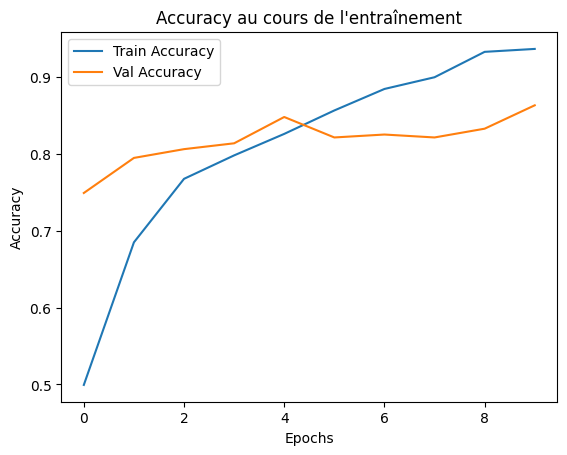

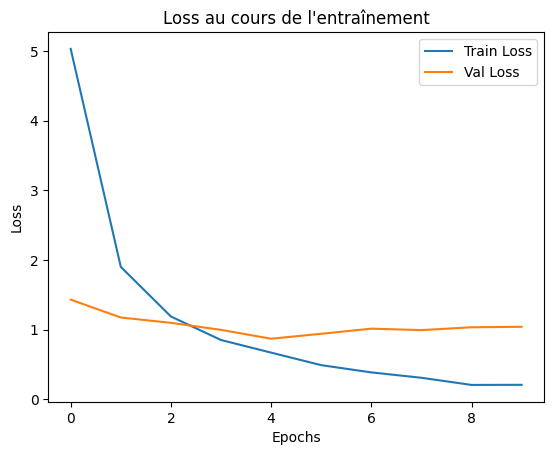

In [15]:
# ─── VISUALISATION DE L’HISTORIQUE ───────────────────────────────────────────
import matplotlib.pyplot as plt

plt.plot(history1.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy au cours de l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.title('Loss au cours de l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step
                            precision    recall  f1-score   support

                 Baby Care       0.85      0.74      0.79        38
  Beauty and Personal Care       0.81      0.78      0.79        37
                 Computers       0.90      0.92      0.91        38
Home Decor & Festive Needs       0.72      0.82      0.77        38
           Home Furnishing       0.87      0.87      0.87        38
          Kitchen & Dining       0.82      0.89      0.86        37
                   Watches       1.00      0.92      0.96        37

                  accuracy                           0.85       263
                 macro avg       0.85      0.85      0.85       263
              weighted avg       0.85      0.85      0.85       263



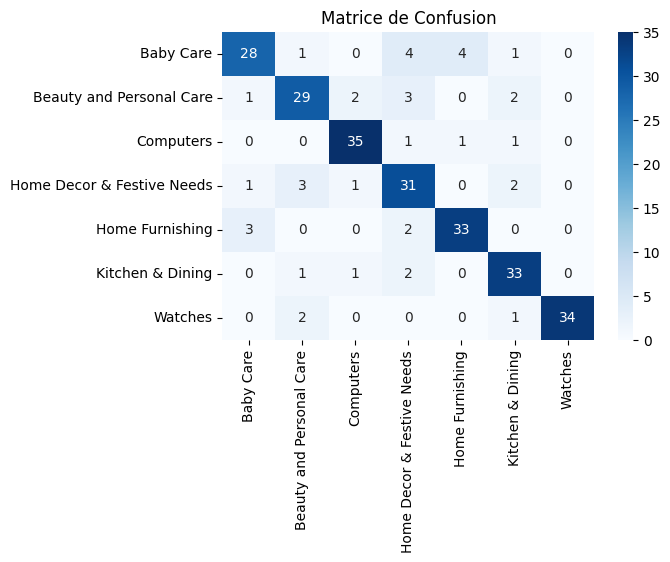

In [17]:
# ─── PRÉDICTIONS ────────────────────────────────────────────────────────────
y_val_pred = np.argmax(model1.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

# ─── RAPPORT DE CLASSIFICATION ──────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(y_val_true, y_val_pred, target_names=le.classes_))

conf_mat = confusion_matrix(y_val_true, y_val_pred)
df_cm = pd.DataFrame(conf_mat, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(df_cm, annot=True, cmap="Blues", fmt='d')
plt.title("Matrice de Confusion")
plt.show()

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Approche 2 — ImageDataGenerator avec Data Augmentation
</div>

Dans cette seconde approche, nous avons repris exactement le même modèle VGG16 gelé, mais cette fois en appliquant de la data augmentation (rotations, décalages, retournements).
Cela permet de simuler plus de diversité dans les images d’entraînement et de renforcer la robustesse du modèle.
Le modèle reste identique, mais l’entraînement bénéficie de plus de variabilité visuelle.

In [19]:
# ─── MÉLANGE DES DONNÉES ────────────────────────────────────────────────────
df_images = df_images.sample(frac=1, random_state=42).reset_index(drop=True)

In [21]:
# ─── DATA AUGMENTATION ──────────────────────────────────────────────────────
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32

datagen_train = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.25,
    preprocessing_function=preprocess_input
)

datagen_test = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ─── FONCTION DE FLUX ───────────────────────────────────────────────────────
def data_flow_fct(dataframe, datagen, data_type=None):
    return datagen.flow_from_dataframe(
        dataframe,
        x_col='image_path',
        y_col='main_category',
        target_size=(224, 224),
        class_mode='categorical',
        batch_size=batch_size,
        shuffle=True,
        seed=42,
        subset=data_type
    )

train_flow = data_flow_fct(df_images, datagen_train, data_type='training')
val_flow = data_flow_fct(df_images, datagen_train, data_type='validation')

Found 788 validated image filenames belonging to 7 classes.
Found 262 validated image filenames belonging to 7 classes.


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Création du Modèle VGG16
</div>

In [25]:
# ─── CRÉATION DU MODÈLE ─────────────────────────────────────────────────────
model2 = create_model_fct()
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,3

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Entraînement du Modèle
</div>

In [27]:
# ─── CALLBACKS ─────────────────────────────────────────────────────────────
model2_save_path = "./model2_best_weights.h5"
checkpoint2 = ModelCheckpoint(model2_save_path, monitor='val_loss', save_best_only=True, mode='min')
es2 = EarlyStopping(monitor='val_loss', mode='min', patience=5)
callbacks_list2 = [checkpoint2, es2]

# ─── ENTRAÎNEMENT ───────────────────────────────────────────────────────────
history2 = model2.fit(
    train_flow,
    validation_data=val_flow,
    epochs=50,
    callbacks=callbacks_list2,
    verbose=1
)

C:\Users\chouh\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
 4/25 ━━━━━━━━━━━━━━━━━━━━ 1:32 4s/step - accuracy: 0.1589 - loss: 9.3904 

C:\Users\chouh\anaconda3\Lib\site-packages\PIL\Image.py:3368: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3402 - loss: 6.0956  

25/25 ━━━━━━━━━━━━━━━━━━━━ 165s 7s/step - accuracy: 0.3444 - loss: 6.0228 - val_accuracy: 0.7672 - val_loss: 1.0917
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6590 - loss: 1.6771  

25/25 ━━━━━━━━━━━━━━━━━━━━ 164s 7s/step - accuracy: 0.6589 - loss: 1.6764 - val_accuracy: 0.8053 - val_loss: 0.8127
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7583 - loss: 1.0911  

25/25 ━━━━━━━━━━━━━━━━━━━━ 168s 7s/step - accuracy: 0.7578 - loss: 1.0908 - val_accuracy: 0.8092 - val_loss: 0.7960
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7575 - loss: 1.0217  

25/25 ━━━━━━━━━━━━━━━━━━━━ 163s 7s/step - accuracy: 0.7573 - loss: 1.0193 - val_accuracy: 0.8244 - val_loss: 0.7020
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 151s 6s/step - accuracy: 0.8141 - loss: 0.6742 - val_accuracy: 0.8015 - val_loss: 0.8409
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 150s 6s/step - accuracy: 0.8225 - loss: 0.6636 - val_accuracy: 0.8092 - val_loss: 0.7142
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 148s 6s/step - accuracy: 0.8667 - loss: 0.4489 - val_accuracy: 0.8359 - val_loss: 0.7514
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 147s 6s/step - accuracy: 0.8667 - loss: 0.3904 - val_accuracy: 0.8092 - val_loss: 0.7754
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 150s 6s/step - accuracy: 0.8745 - loss: 0.4006 - val_accuracy: 0.8321 - val_loss: 0.7252


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Évaluation du Modèle
</div>

In [29]:
# ─── ÉVALUATION SUR LE JEU DE VALIDATION ────────────────────────────────────
model2.load_weights(model2_save_path)

loss, accuracy = model2.evaluate(val_flow, verbose=0)
print(f"Validation Accuracy : {accuracy:.4f}")

Validation Accuracy : 0.8130


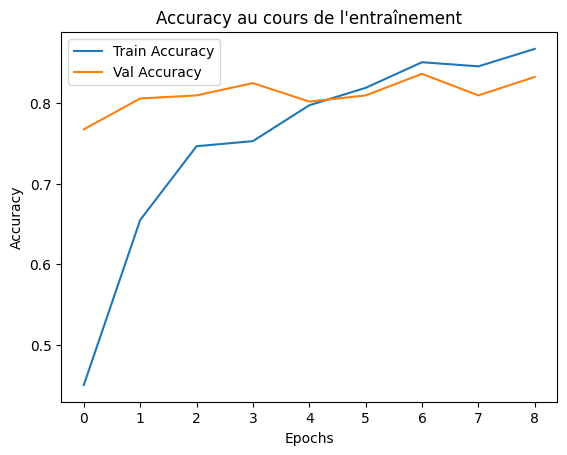

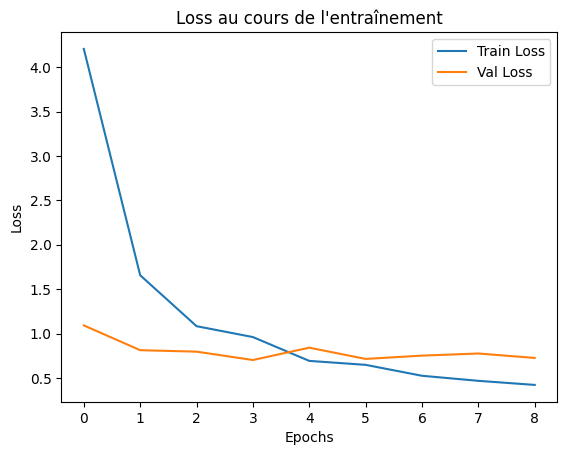

In [31]:
# ─── VISUALISATION DE L’HISTORIQUE ───────────────────────────────────────────
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy au cours de l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Loss au cours de l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 51s 6s/step
                            precision    recall  f1-score   support

                 Baby Care       0.76      0.63      0.69        41
  Beauty and Personal Care       0.86      0.77      0.81        39
                 Computers       0.79      0.86      0.83        36
Home Decor & Festive Needs       0.71      0.83      0.76        29
           Home Furnishing       0.65      0.86      0.74        37
          Kitchen & Dining       0.94      0.79      0.86        38
                   Watches       1.00      0.93      0.96        42

                  accuracy                           0.81       262
                 macro avg       0.82      0.81      0.81       262
              weighted avg       0.82      0.81      0.81       262



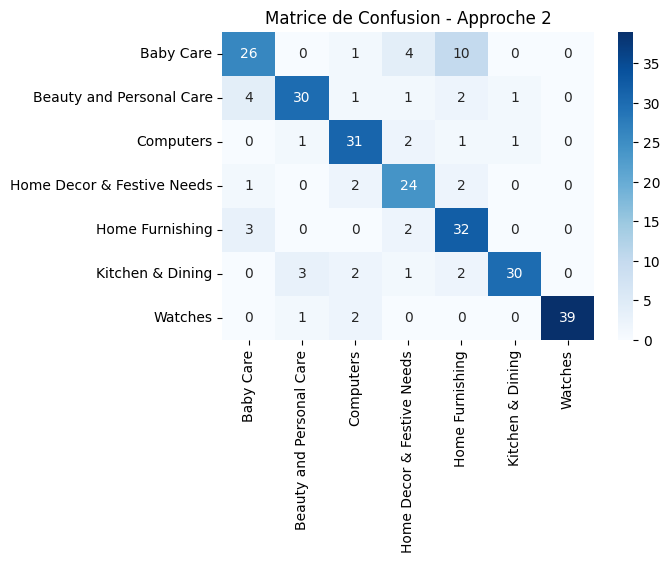

In [88]:
# ─── RECONSTRUCTION DE X_val ET y_val ───────────────────────────────────────
X_val_rebuilt, y_val_rebuilt = [], []

for i in range(len(val_flow)):
    batch_x, batch_y = val_flow[i]
    X_val_rebuilt.append(batch_x)
    y_val_rebuilt.append(batch_y)

# Fusion de tous les batches
import numpy as np

X_val_rebuilt = np.concatenate(X_val_rebuilt)
y_val_rebuilt = np.concatenate(y_val_rebuilt)

# ─── PRÉDICTIONS ────────────────────────────────────────────────────────────
y_val_pred2 = np.argmax(model2.predict(X_val_rebuilt), axis=1)
y_val_true2 = np.argmax(y_val_rebuilt, axis=1)

# ─── RAPPORT DE CLASSIFICATION ──────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_val_true2, y_val_pred2, target_names=val_flow.class_indices.keys()))

conf_mat2 = confusion_matrix(y_val_true2, y_val_pred2)
df_cm2 = pd.DataFrame(conf_mat2, index=val_flow.class_indices.keys(), columns=val_flow.class_indices.keys())

plt.figure(figsize=(6, 4))
sns.heatmap(df_cm2, annot=True, cmap="Blues", fmt='d')
plt.title("Matrice de Confusion - Approche 2")
plt.show()

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Approche 3 — Dataset TensorFlow avec Répertoire Structuré
</div>

Dans cette dernière approche, nous avons réorganisé les images pour utiliser le format Dataset TensorFlow.
Cela permet une gestion optimisée des flux de données et améliore la performance d’entraînement.
Le modèle reste basé sur VGG16 gelé, toujours avec data augmentation, mais la méthode de préparation des données est plus adaptée à des environnements de production.

In [43]:
# ─── ORGANISATION DES IMAGES POUR DATASET TF ────────────────────────────────
import os
import shutil

# Dossier cible pour TensorFlow
output_dir = r'C:\Users\chouh\OneDrive\Desktop\Openclassrooms\Formation Data Scientist\projet 6\Flipkart\Images_TF'

# Création des dossiers par catégorie
for category in df_images['main_category'].unique():
    category_dir = os.path.join(output_dir, category)
    os.makedirs(category_dir, exist_ok=True)

# Copie des images dans les bons dossiers
for _, row in df_images.iterrows():
    src = row['image_path']
    dst = os.path.join(output_dir, row['main_category'], os.path.basename(src))
    shutil.copy2(src, dst)

print("Organisation terminée dans :", output_dir)

Organisation terminée dans : C:\Users\chouh\OneDrive\Desktop\Openclassrooms\Formation Data Scientist\projet 6\Flipkart\Images_TF


In [45]:
image_dir_tf = output_dir

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Création du Modèle VGG16
</div>

In [47]:
# ─── CRÉATION DU DATASET ────────────────────────────────────────────────────
import tensorflow as tf

batch_size = 32

def dataset_fct(directory_path, validation_split=0, data_type=None):
    return tf.keras.utils.image_dataset_from_directory(
        directory_path,
        labels='inferred',
        label_mode='categorical',
        batch_size=batch_size,
        image_size=(224, 224),
        shuffle=True,
        seed=42,
        validation_split=validation_split,
        subset=data_type
    )

# Construction des datasets
dataset_train = dataset_fct(image_dir_tf, validation_split=0.25, data_type='training')
dataset_val   = dataset_fct(image_dir_tf, validation_split=0.25, data_type='validation')

Found 1050 files belonging to 7 classes.
Using 788 files for training.
Found 1050 files belonging to 7 classes.
Using 262 files for validation.


In [49]:
# ─── CRÉATION DU MODÈLE ─────────────────────────────────────────────────────
model3 = create_model_fct()
model3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         131,3

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Entraînement du Modèle
</div>

In [51]:
# ─── CALLBACKS ─────────────────────────────────────────────────────────────
model3_save_path = "./model3_best_weights.h5"
checkpoint3 = ModelCheckpoint(model3_save_path, monitor='val_loss', save_best_only=True, mode='min')
es3 = EarlyStopping(monitor='val_loss', mode='min', patience=5)
callbacks_list3 = [checkpoint3, es3]

# ─── ENTRAÎNEMENT ───────────────────────────────────────────────────────────
history3 = model3.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=50,
    callbacks=callbacks_list3,
    verbose=1
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3554 - loss: 8.2415   

25/25 ━━━━━━━━━━━━━━━━━━━━ 223s 9s/step - accuracy: 0.3602 - loss: 8.1280 - val_accuracy: 0.7443 - val_loss: 1.5214
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6446 - loss: 2.3091  

25/25 ━━━━━━━━━━━━━━━━━━━━ 217s 9s/step - accuracy: 0.6455 - loss: 2.3027 - val_accuracy: 0.7519 - val_loss: 1.5103
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7497 - loss: 1.1829  

25/25 ━━━━━━━━━━━━━━━━━━━━ 214s 9s/step - accuracy: 0.7496 - loss: 1.1860 - val_accuracy: 0.7901 - val_loss: 1.0682
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 207s 8s/step - accuracy: 0.7549 - loss: 0.8987 - val_accuracy: 0.8130 - val_loss: 1.0753
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8374 - loss: 0.6874  

25/25 ━━━━━━━━━━━━━━━━━━━━ 207s 8s/step - accuracy: 0.8375 - loss: 0.6847 - val_accuracy: 0.8168 - val_loss: 0.9891
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 207s 8s/step - accuracy: 0.8541 - loss: 0.4606 - val_accuracy: 0.8397 - val_loss: 1.0286
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 206s 8s/step - accuracy: 0.8954 - loss: 0.3526 - val_accuracy: 0.8206 - val_loss: 1.0346
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9174 - loss: 0.2999  

25/25 ━━━━━━━━━━━━━━━━━━━━ 205s 8s/step - accuracy: 0.9172 - loss: 0.3014 - val_accuracy: 0.8282 - val_loss: 0.9818
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 207s 8s/step - accuracy: 0.9385 - loss: 0.2192 - val_accuracy: 0.8168 - val_loss: 1.0547
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9166 - loss: 0.2464  

25/25 ━━━━━━━━━━━━━━━━━━━━ 209s 8s/step - accuracy: 0.9168 - loss: 0.2460 - val_accuracy: 0.8206 - val_loss: 0.9667
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 207s 8s/step - accuracy: 0.9402 - loss: 0.2002 - val_accuracy: 0.8206 - val_loss: 0.9687
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 207s 8s/step - accuracy: 0.9609 - loss: 0.1416 - val_accuracy: 0.8473 - val_loss: 1.0193
Epoch 13/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 207s 8s/step - accuracy: 0.9520 - loss: 0.1783 - val_accuracy: 0.8321 - val_loss: 1.0894
Epoch 14/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 206s 8s/step - accuracy: 0.9572 - loss: 0.1202 - val_accuracy: 0.8282 - val_loss: 1.1124
Epoch 15/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 207s 8s/step - accuracy: 0.9762 - loss: 0.0778 - val_accuracy: 0.8511 - val_loss: 1.0075


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Évaluation du Modèle
</div>

In [53]:
# ─── ÉVALUATION ─────────────────────────────────────────────────────────────
model3.load_weights(model3_save_path)

loss, accuracy = model3.evaluate(dataset_val, verbose=0)
print(f"Validation Accuracy : {accuracy:.4f}")

Validation Accuracy : 0.8206


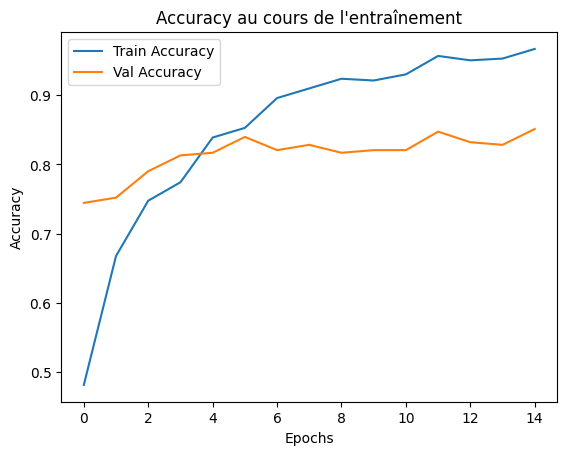

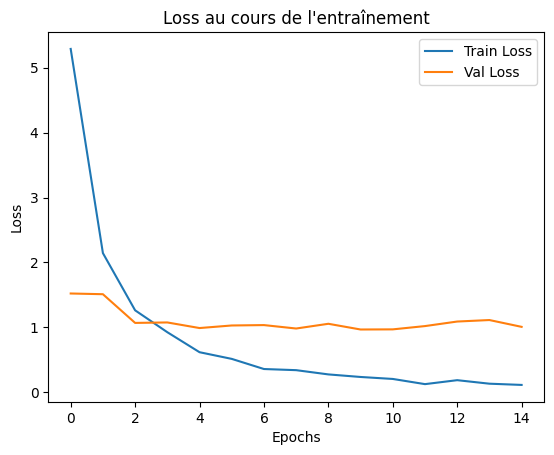

In [55]:
# ─── VISUALISATION DE L’HISTORIQUE ───────────────────────────────────────────
import matplotlib.pyplot as plt

plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy au cours de l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Val Loss')
plt.title('Loss au cours de l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 52s 6s/step
                            precision    recall  f1-score   support

                 Baby Care       0.75      0.62      0.68        29
  Beauty and Personal Care       0.69      0.79      0.74        34
                 Computers       0.89      0.80      0.84        30
Home Decor & Festive Needs       0.78      0.82      0.79        38
           Home Furnishing       0.79      0.86      0.82        43
          Kitchen & Dining       0.91      0.87      0.89        46
                   Watches       0.93      0.90      0.92        42

                  accuracy                           0.82       262
                 macro avg       0.82      0.81      0.81       262
              weighted avg       0.82      0.82      0.82       262



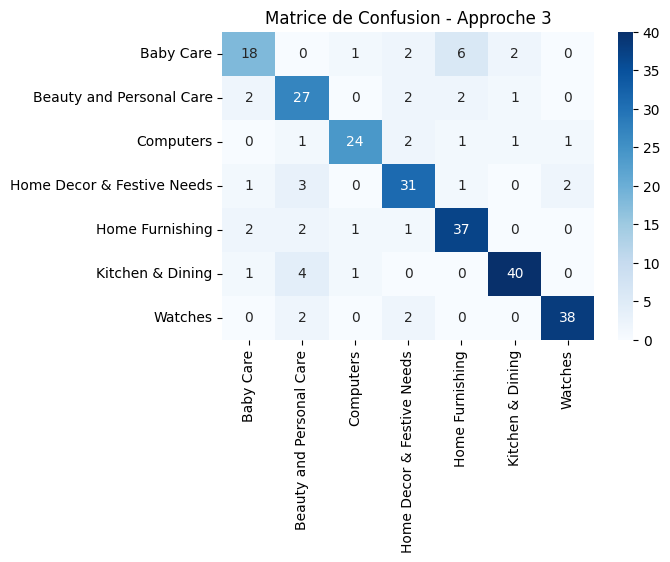

In [90]:
# ─── RECONSTRUCTION DE X_val ET y_val ───────────────────────────────────────
X_val_rebuilt, y_val_rebuilt = [], []

for batch_x, batch_y in dataset_val:
    X_val_rebuilt.append(batch_x)
    y_val_rebuilt.append(batch_y)

# Fusion de tous les batches
import numpy as np

X_val_rebuilt = np.concatenate(X_val_rebuilt)
y_val_rebuilt = np.concatenate(y_val_rebuilt)

# ─── PRÉDICTIONS ────────────────────────────────────────────────────────────
y_val_pred3 = np.argmax(model3.predict(X_val_rebuilt), axis=1)
y_val_true3 = np.argmax(y_val_rebuilt, axis=1)

# ─── RAPPORT DE CLASSIFICATION ──────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_val_true3, y_val_pred3, target_names=dataset_val.class_names))

conf_mat3 = confusion_matrix(y_val_true3, y_val_pred3)
df_cm3 = pd.DataFrame(conf_mat3, index=dataset_val.class_names, columns=dataset_val.class_names)

plt.figure(figsize=(6, 4))
sns.heatmap(df_cm3, annot=True, cmap="Blues", fmt='d')
plt.title("Matrice de Confusion - Approche 3")
plt.show()

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Conclusion
</div>

In [59]:
import pandas as pd

# Saisissez ici les scores observés pour chaque approche
scores = {
    "Approche": ["Approche 1 - Sans Data Aug", "Approche 2 - Data Aug", "Approche 3 - Dataset TF"],
    "Validation Accuracy": [0.8479, 0.8130, 0.8206]  # Remplace par tes vraies valeurs
}

df_scores = pd.DataFrame(scores)
df_scores

,Approche,Validation Accuracy
0,Approche 1 - Sans Data Aug,0.8479
1,Approche 2 - Data Aug,0.8130
2,Approche 3 - Dataset TF,0.8206
